## K-Armed Bandit

- Jacquelyn Xu (gqj3wx)
- Reproduce the two plots in Figure 2.2 by comparing epsilon values of 0, 0.01, and 0.1 over 2,000 runs of 1,000 steps.
### Findings: 
- higher epsilon values increase the optimal action percentage as well as higher reward obtained by the agent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Bandit environment

- stores one true mean reward for each arm
- Sample these means from a normal distribution with mean = 0, sd = 1.
- Keep the means fixed during one run; generate each observed reward around the chosen arm's mean.

In [2]:
class BanditEnvironment:
    # constructor for the variables in the bandit game
    def __init__(self, num_arms=10, seed=None):
        # store the number of arms and create a random number generator
        self.num_arms = num_arms
        self.rng = np.random.default_rng(seed)

        # sample one true mean reward for each arm
        self.true_means = self.rng.normal(loc=0, scale=1, size=num_arms)
        # store the index of the arm with the highest true mean
        self.best_arm = np.argmax(self.true_means)

    # generate one reward from the chosen arm
    def step(self, arm):
        # sample around this arm's true mean with standard deviation 1
        return self.rng.normal(loc=self.true_means[arm], scale=1)

## Agent

- Initiate the rewards and selection counts as zero, and implement epsilon as a probability variable for random exploration of the arms
- 1 - epsilon being the probability to chose arms in a greedy fashion, selecting any of the top reward (equal reward) best arms
- Keep action selection and learning in separate methods.

- Update only the chosen arm: new estimate = old estimate + (observed reward - old estimate) / selection count.


In [3]:
class EpsilonGreedyAgent:
    def __init__(self, num_arms=10, epsilon=0.1, seed=None):
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)

        # create one estimated mean reward per arm, initially zero
        self.reward_estimates = np.zeros(num_arms)
        # count how many times each arm has been chosen
        self.arm_counts = np.zeros(num_arms, dtype=int)

    # choose an arm using the exploration or greedy strategy
    def select_action(self):
        decision = self.rng.choice(
            ["explore", "greedy"],
            p=[self.epsilon, 1 - self.epsilon]
        )

        if decision == "explore":
            # randomly choose from all arms
            return self.rng.integers(self.num_arms)
        else:
            # find all arm indices tied for the highest estimated reward
            highest_estimate = self.reward_estimates.max()
            best_arms = np.flatnonzero(self.reward_estimates == highest_estimate)
            # randomly choose one of those tied arms
            return self.rng.choice(best_arms)

    # learn from the chosen arm and its observed reward
    def update(self, arm, reward):
        # include the current selection in this arm's count
        self.arm_counts[arm] += 1
        # move the estimate toward the observed reward using a sample average
        difference = reward - self.reward_estimates[arm]
        self.reward_estimates[arm] += difference / self.arm_counts[arm]

## One run logic

- create a fresh environment and agent, then interact for 1,000 steps.
- At each step, choose one arm, observe one reward, and update that arm's estimate.
- Record the reward and whether the chosen arm was optimal for the two plots.

In [4]:
def run_one_game(epsilon, num_steps=1000, num_arms=10):
    # create a new bandit problem and an agent with no previous experience
    bandit = BanditEnvironment(num_arms=num_arms)
    agent = EpsilonGreedyAgent(num_arms=num_arms, epsilon=epsilon)

    # allocate one entry for each step's reward and optimal action result
    step_rewards = np.zeros(num_steps)
    optimal_choices = np.zeros(num_steps)

    for step_index in range(num_steps):
        # choose one arm, observe its reward, and learn from it
        chosen_arm = agent.select_action()
        reward = bandit.step(chosen_arm)
        agent.update(chosen_arm, reward)

        # record the reward for this step
        step_rewards[step_index] = reward
        # record 1 for an optimal choice and 0 otherwise
        if chosen_arm == bandit.best_arm:
            optimal_choices[step_index] = 1
        else:
            optimal_choices[step_index] = 0

    return step_rewards, optimal_choices

## Repeated runs

- *repeat each epsilon setting 2,000 times.*
- Each result array has shape (3, 1000): rows are epsilon settings, columns are steps.
- Add each run's results to the matching row, then divide by the number of runs.
- Multiply the optimal-action fraction by 100 to get a percentage.
- Average across runs at each step, not across earlier steps.

In [5]:
def run_experiment(epsilon_values=(0, 0.01, 0.1), num_runs=2000, num_steps=1000):
    # create one row per epsilon and one column per step
    mean_rewards = np.zeros((len(epsilon_values), num_steps))
    optimal_rates = np.zeros((len(epsilon_values), num_steps))

    # row_index identifies the current epsilon setting
    for row_index, epsilon in enumerate(epsilon_values):
        for run_index in range(num_runs):
            # get a complete reward and optimal choice array from a fresh run
            step_rewards, optimal_choices = run_one_game(
                epsilon=epsilon, num_steps=num_steps
            )
            # add matching steps to the current epsilon's row
            mean_rewards[row_index] += step_rewards
            optimal_rates[row_index] += optimal_choices

        # convert this row's totals into averages and percentages
        mean_rewards[row_index] /= num_runs
        optimal_rates[row_index] *= 100 / num_runs

    return mean_rewards, optimal_rates

## Run the experiment

- *use all 2,000 runs and 1,000 steps for each epsilon.*
- Random sampling means the exact curves can change when the notebook is rerun.

In [6]:
epsilon_values = (0, 0.01, 0.1)

mean_rewards, optimal_rates = run_experiment(
    epsilon_values=epsilon_values,
    num_runs=2000,
    num_steps=1000
)

# check that both arrays have one row per epsilon and one column per step
print("Mean rewards shape:", mean_rewards.shape)
print("Optimal action percentages shape:", optimal_rates.shape)

Mean rewards shape: (3, 1000)
Optimal action percentages shape: (3, 1000)


## Visualization

- *show average reward above and optimal-action percentage below.*
- Use steps 1 through 1,000 and place both legends outside the plots.
- Save the notebook after running all cells so both plots remain visible.

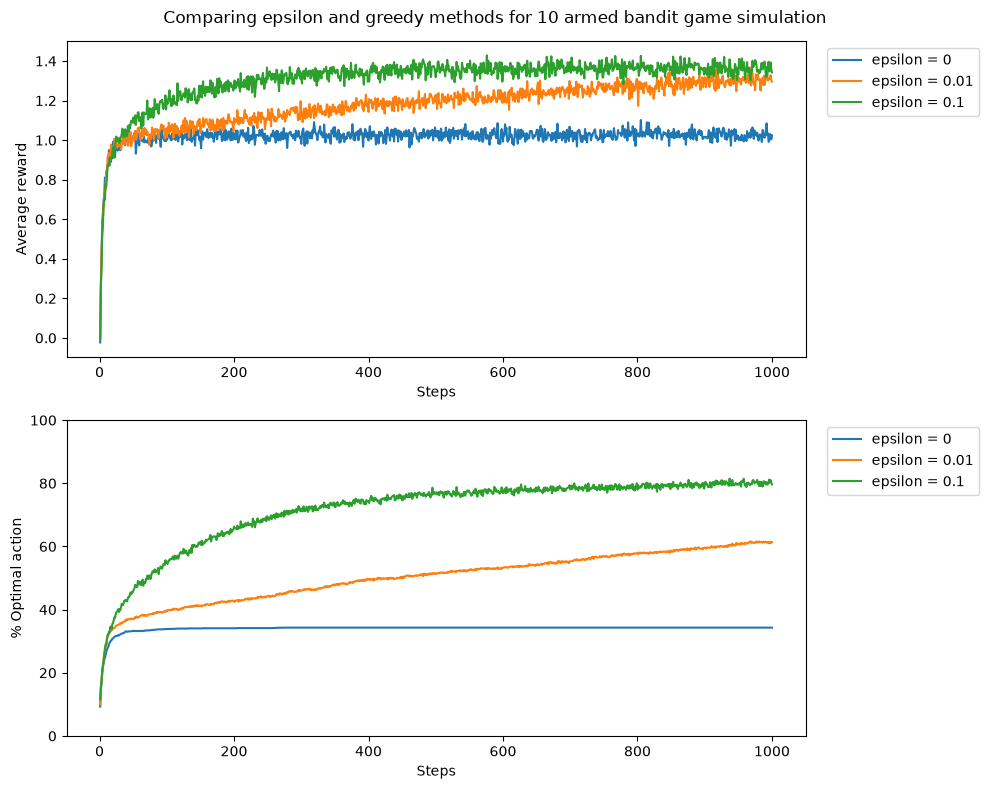

In [7]:
# create one x-coordinate for every recorded step
step_numbers = np.arange(1, mean_rewards.shape[1] + 1)

figure, plots = plt.subplots(2, 1, figsize=(10, 8))
figure.suptitle("Comparing epsilon and greedy methods for 10 armed bandit game simulation")

# plot one curve for each epsilon setting on both graphs
for row_index, epsilon in enumerate(epsilon_values):
    curve_label = f"epsilon = {epsilon}"
    plots[0].plot(step_numbers, mean_rewards[row_index], label=curve_label)
    plots[1].plot(step_numbers, optimal_rates[row_index], label=curve_label)

# label the average reward plot
plots[0].set_xlabel("Steps")
plots[0].set_ylabel("Average reward")
plots[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1))

# label the optimal action plot
plots[1].set_xlabel("Steps")
plots[1].set_ylabel("% Optimal action")
plots[1].set_ylim(0, 100)
plots[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))

# leave room for the title and display both plots in the notebook
plt.tight_layout()
plt.show()

## Observations

- *Greedy agents can settle on a suboptimal arm because they stop exploring alternatives.*
- Exploration helps agents discover better arms, improving performance over these 1,000 steps.
- Reference: [Shangtong Zhang's 10-armed testbed implementation](https://github.com/ShangtongZhang/reinforcement-learning-an-introduction/blob/master/chapter02/ten_armed_testbed.py).